<a href="https://colab.research.google.com/github/hanjeongseop/Data/blob/main/3_CDA(%ED%99%95%EC%A6%9D%EC%A0%81_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import subprocess
subprocess.run(['apt-get', '-qq', '-y', 'install', 'fonts-nanum'])

import matplotlib
import shutil, os

cache_dir = matplotlib.get_cachedir()
shutil.rmtree(cache_dir, ignore_errors=True)
os.makedirs(cache_dir, exist_ok=True)
print("✓ 설치 완료. 런타임을 재시작하세요.")

✓ 설치 완료. 런타임을 재시작하세요.


In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = fm.findfont(fm.FontProperties(family='NanumGothic'))
fm.fontManager.addfont(font_path)

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print(f"✓ 폰트 적용: {font_path}")

✓ 폰트 적용: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


# III. CDA (확증적 데이터 분석)

## 1. 각 설비 별 공정시간에 유의미한 차이가 있을까?

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
# 파일 읽기 및 내용 확인하기

github_csv_url = 'https://raw.githubusercontent.com/hanjeongseop/Data/main'

df1 = pd.read_csv(github_csv_url + '/preprocessing_data.csv')

df1

,Unnamed: 0,Ox_Chamber,process,type,Temp_OXid,Vapor,ppm,Pressure,Oxid_time,thickness,...,Flux480s,Flux840s,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,Target,Error_message,target_binom,Chamber_Route
0,0,1,Oxidation,dry,1138.979159,O2,32.80,0.200,62.0,699.443,...,3.002593e+17,6.000007e+17,31574.410,102.847,885.0,154,96,none,0.0,route_11133
1,1,1,Oxidation,dry,1218.184551,O2,31.86,0.194,137.0,696.792,...,3.017903e+17,6.000012e+17,31580.213,104.323,919.0,154,102,none,0.0,route_11222
2,2,1,Oxidation,dry,1062.467808,O2,39.51,0.217,128.0,705.471,...,2.994231e+17,6.000002e+17,32162.414,100.605,916.0,155,95,none,0.0,route_11311
3,3,1,Oxidation,dry,1114.704773,O2,32.88,0.201,90.0,710.772,...,2.991354e+17,6.000003e+17,32874.925,101.739,911.0,156,117,none,0.0,route_12111
4,4,1,Oxidation,dry,989.411946,O2,38.11,0.204,98.0,716.975,...,3.005576e+17,6.000013e+17,30985.928,106.422,872.0,155,143,none,0.0,route_12222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,845,3,Oxidation,wet,1280.687973,H2O,45.19,0.214,21.0,708.586,...,2.995317e+17,5.999986e+17,32252.961,101.177,868.0,152,84,none,0.0,route_33111
748,846,3,Oxidation,wet,1275.153349,H2O,45.08,0.215,22.0,712.936,...,3.004926e+17,5.999991e+17,32253.818,100.736,868.0,151,105,none,0.0,route_33222
749,847,3,Oxidation,wet,1275.182502,H2O,45.10,0.214,21.0,715.498,...,3.009325e+17,6.000003e+17,32248.621,101.503,868.0,152,78,none,0.0,route_33333
750,848,1,Oxidation,wet,1268.105427,H2O,45.07,0.215,22.0,707.179,...,3.006733e+17,6.000003e+17,32241.426,101.061,867.0,152,42,none,0.0,route_11133


In [4]:
df1_oxid = df1[['Reinforcement','Oxid_time']]

<Axes: xlabel='Reinforcement', ylabel='Oxid_time'>

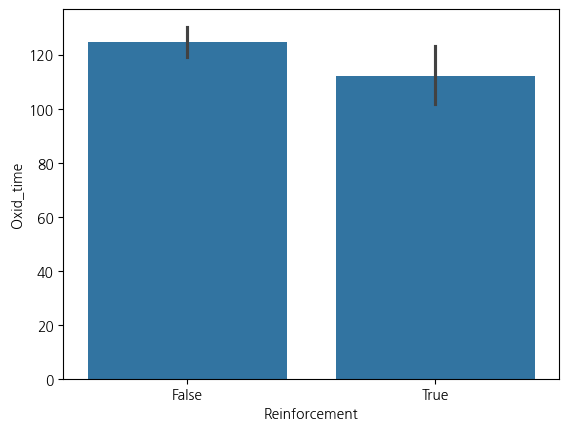

In [5]:
# 보강여부와 공정시간의 차이가 있을까?

sns.barplot(data=df1_oxid, x='Reinforcement', y='Oxid_time')

In [6]:
# 귀무가설 : 보강 여부에 따라 공정시간의 평균값에 차이가 없다.
# 대립가설 : 보강 여부에 따라 공정시간 평균값에 차이가 있다.

import scipy.stats as stats

<Axes: xlabel='Oxid_time', ylabel='Count'>

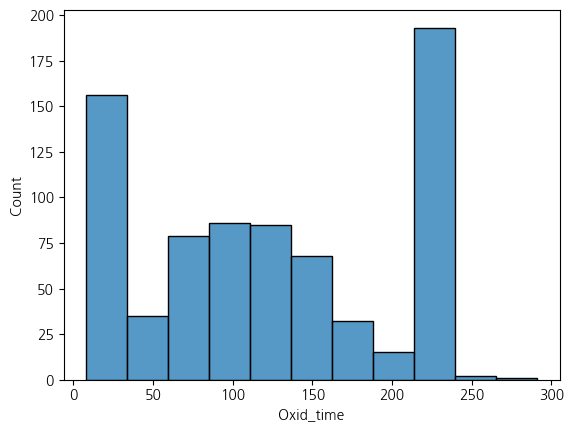

In [7]:
# 보강 여부 : 범주형 / Y : 연속형
# 1-1. Oxid time 데이터가 정규분포를 띄는가?

sns.histplot(data=df1, x='Oxid_time')

In [8]:
# 귀무가설 : Oxid time 데이터 정규분포와 같다.
# 대립가설 : Oxid time 데이터 정규분포와 다르다.


# 통계량과 pvalue값을 구할 수 있는 함수를 사용
stats.normaltest(df1['Oxid_time'])

NormaltestResult(statistic=np.float64(7323.6988862575145), pvalue=np.float64(0.0))

# [해석]

# p.value가 0이다

# 유의수준 : 가설검정의 판단기준인 5%를 기준으로 한다.
# p.value > 5% : 귀무가설 참
# p.value < 5% : 대립가설 참

# P.value < 5% (0.05)
# 통계적 결론 : 대립가설 참
# 사실적 결론 : 해당 데이터의 분포는 정규분포를 띄지 않는다.

In [9]:
# 1-2. 보강 여부에 따라 공정시간의 차이가 있는지 검정
# (비정규, 2집단    wilcoxon  -> ranksum 함수를 이용)
# 윌콕슨 순위합검정 : 모집단의 분포를 모르는 경우에 시행하는 비모수검정 방법

cond1 = (df1['Reinforcement'] == True)
df1_rein = df1.loc[cond1]

cond2 = (df1['Reinforcement'] == False)
df1_nonrein = df1.loc[cond2]

In [10]:
# 귀무가설 : 보강 여부에 따라 공정시간의 평균값에 차이가 없다.
# 대립가설 : 보강 여부에 따라 공정시간 평균값에 차이가 있다.

stats.ranksums(df1_rein['Oxid_time'], df1_nonrein['Oxid_time'])

RanksumsResult(statistic=np.float64(-0.972244747533458), pvalue=np.float64(0.3309288040213433))

### [해석]
### p.value가 0.33이다

### P.value > 0.05
### 통계적 결론 : 귀무가설 참
### 사실적 결론 : 보강 여부에 따라 공정시간의 평균값에 차이가 없다.

## 2. 특정 설비에 따라서 공정 안정 여부가 달라질까?

### 범주형 vs 범주형

In [11]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [12]:
df1 = pd.read_csv(github_csv_url + '/preprocessing_data.csv')

df1

,Unnamed: 0,Ox_Chamber,process,type,Temp_OXid,Vapor,ppm,Pressure,Oxid_time,thickness,...,Flux480s,Flux840s,input_Energy,Temp_implantation,Furance_Temp,RTA_Temp,Target,Error_message,target_binom,Chamber_Route
0,0,1,Oxidation,dry,1138.979159,O2,32.80,0.200,62.0,699.443,...,3.002593e+17,6.000007e+17,31574.410,102.847,885.0,154,96,none,0.0,route_11133
1,1,1,Oxidation,dry,1218.184551,O2,31.86,0.194,137.0,696.792,...,3.017903e+17,6.000012e+17,31580.213,104.323,919.0,154,102,none,0.0,route_11222
2,2,1,Oxidation,dry,1062.467808,O2,39.51,0.217,128.0,705.471,...,2.994231e+17,6.000002e+17,32162.414,100.605,916.0,155,95,none,0.0,route_11311
3,3,1,Oxidation,dry,1114.704773,O2,32.88,0.201,90.0,710.772,...,2.991354e+17,6.000003e+17,32874.925,101.739,911.0,156,117,none,0.0,route_12111
4,4,1,Oxidation,dry,989.411946,O2,38.11,0.204,98.0,716.975,...,3.005576e+17,6.000013e+17,30985.928,106.422,872.0,155,143,none,0.0,route_12222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,845,3,Oxidation,wet,1280.687973,H2O,45.19,0.214,21.0,708.586,...,2.995317e+17,5.999986e+17,32252.961,101.177,868.0,152,84,none,0.0,route_33111
748,846,3,Oxidation,wet,1275.153349,H2O,45.08,0.215,22.0,712.936,...,3.004926e+17,5.999991e+17,32253.818,100.736,868.0,151,105,none,0.0,route_33222
749,847,3,Oxidation,wet,1275.182502,H2O,45.10,0.214,21.0,715.498,...,3.009325e+17,6.000003e+17,32248.621,101.503,868.0,152,78,none,0.0,route_33333
750,848,1,Oxidation,wet,1268.105427,H2O,45.07,0.215,22.0,707.179,...,3.006733e+17,6.000003e+17,32241.426,101.061,867.0,152,42,none,0.0,route_11133


In [13]:
# 레이저 타입과 적정성범주와의 관계를 확인해보자 ( 범주형 vs 범주형)

df1_uv = df1[['UV_type','Range_check']]
pd.crosstab(df1_uv['UV_type'], df1_uv['Range_check'])

Range_check,False,True
UV_type,,
G,36,234
H,86,170
I,40,186


In [14]:
# H라인인 경우 문제가 있어보인다.
# 적정성을 확인하기위해 별도 데이터셋저장.

df1_contingency = pd.crosstab(df1_uv['UV_type'], df1_uv['Range_check'])
df1_contingency

Range_check,False,True
UV_type,,
G,36,234
H,86,170
I,40,186


In [15]:
# 귀무가설 : 레이저 종류(UV Type)에 따라 선폭의 적정여부(True/False)의 유의미한 차이가 없다
#            ( 두 범주형 변수가 서로 독립적이다)
# 대립가설 : 레이저 종류(UV Type)에 따라 선폭의 적정여부(True/False)의 유의미한 차이가 있다
#            ( 두 범주형 변수가 서로 연관성이 있다)

# 카이제곱 검정 : 변수간 연관성을 확인한다.

stats.chi2_contingency(df1_contingency)

Chi2ContingencyResult(statistic=np.float64(34.738055467596986), pvalue=np.float64(2.862378750713432e-08), dof=2, expected_freq=array([[ 58.16489362, 211.83510638],
       [ 55.14893617, 200.85106383],
       [ 48.68617021, 177.31382979]]))

### [해석]

### chi2 통계량 : P.value를 계산하기 위한 값    => 34.73
### p-value (e-08 : 10 ^ -8) : 0.000000002862
### 자유도  => 2
### 기대값 => 모수 추정치
### array([[ 58.16489362, 211.83510638],
###        [ 55.14893617, 200.85106383],
###        [ 48.68617021, 177.31382979]])

##

##### 우리에게 중요한 요소는 p.value이다

### p-value : 0.000000002862
### p-value < 0.05
### 통계적 결론 : 대립가설 참
### 사실적 결론 : 레이저 종류(UV Type)에 따라 선폭의 적정여부(True/False)의 유의미한 차이가 있다
###               ( 두 범주형 변수가 서로 연관성이 있다)

<Axes: xlabel='UV_type', ylabel='count'>

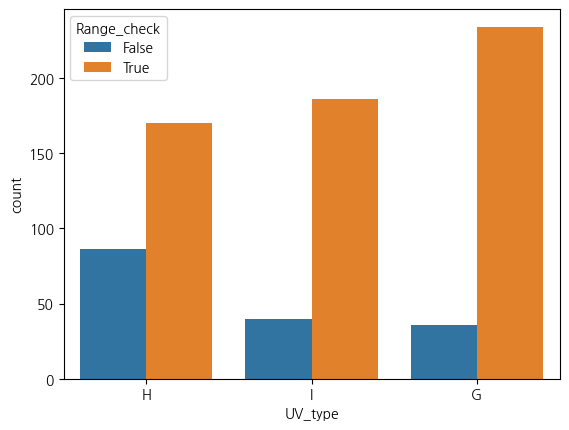

In [16]:
sns.countplot(data=df1, x='UV_type', hue='Range_check')

### [해석]

### ##### 인사이트 도출 ##########

### 1. H라인의 레이저를 사용할 경우 적정선폭을 벗어나는 경우가 많으므로 개선작업이 필요하다.
#### -  Range_check 범주를 벗어나는 경우가 I, G라인에 비해 빈도가 높다.

### 2. H라인의 개선작업 전 까지는 I라인 또는 G라인을 사용해야 한다.

### 3. 통계적 가설검정 절차에서는 가설을 수립하기가 어렵지만 나머지 절차는 쉽게 처리(확인)할 수 있다.

# 전처리 작업을 충실히 수행하자!!!!!

## 3. 각 주요 공정 경로 별 불량 개수의 차이가 있을까?

### 범주형 vs 연속형

In [17]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.stats as stats

In [18]:
df1 = pd.read_csv(github_csv_url + '/chamber_route.csv')

df1

,Unnamed: 0,Chamber_Route,Target,count,error_rate
0,0,route_11111,1415,15,94.333333
1,1,route_11133,1367,13,105.153846
2,2,route_11222,2281,25,91.240000
3,3,route_11311,1811,17,106.529412
4,4,route_11333,1203,14,85.928571
5,5,route_12111,1677,18,93.166667
6,6,route_12133,1519,14,108.500000
7,7,route_12222,2835,20,141.750000
8,8,route_12311,1253,15,83.533333
9,9,route_12333,2152,16,134.500000


In [19]:
# 공정 경로에 따라 부하량과 불량 개수의 유의미한 차이가 있는가?

df1['count'].describe()

,count
count,45.000000
mean,16.711111
std,5.459030
min,8.000000
25%,14.000000
50%,15.000000
75%,17.000000
max,34.000000


In [20]:
# 상위10%에 해당하는 공정을 찾아보자
df1['count'].quantile(0.90)

np.float64(25.6)

In [21]:
cond1 = (df1['count'] > 25)

df1.loc[cond1, '과부하여부'] = '과부하'
df1.loc[~cond1, '과부하여부'] = '정상'

In [22]:
df1

,Unnamed: 0,Chamber_Route,Target,count,error_rate,과부하여부
0,0,route_11111,1415,15,94.333333,정상
1,1,route_11133,1367,13,105.153846,정상
2,2,route_11222,2281,25,91.240000,정상
3,3,route_11311,1811,17,106.529412,정상
4,4,route_11333,1203,14,85.928571,정상
5,5,route_12111,1677,18,93.166667,정상
6,6,route_12133,1519,14,108.500000,정상
7,7,route_12222,2835,20,141.750000,정상
8,8,route_12311,1253,15,83.533333,정상
9,9,route_12333,2152,16,134.500000,정상


<Axes: xlabel='Target', ylabel='Count'>

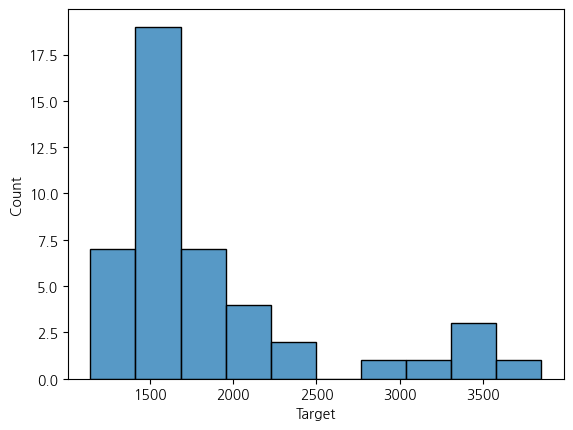

In [23]:
# 집단간의 차이가 있는지 확인해보자.
# 1-1. Target 갑의 정규성 검정

sns.histplot(data=df1, x='Target')

In [24]:
# 정규성을 띄지 않는다.

# 귀무 가설 : Target값은 정규분포를 따른다.
# 대립 가설 : Target값은 정규분포를 따르지 않는다.

stats.normaltest(df1['Target'])

NormaltestResult(statistic=np.float64(19.830161075462293), pvalue=np.float64(4.942369772655265e-05))

### [해석]

### p-value : 4.942369772655265e-05
### P-value < 0.05
### 통계적 결론 : 대립가설 참
### 사실적 결론 : Target값은 정규분포를 따르지 않는다.

In [25]:
# 1-2. (비정규분포) 경로 부하 여부에 따른 불량의 차이가 있는가?

# 귀무 가설 : 부하여부에 따라 불량개수 평균의 차이가 없다.
# 대립 가설 : 부하여부에 따라 불량개수의 평균의 차이가 있다.

cond1 = (df1['과부하여부'] == '과부하')
df1_overload = df1.loc[cond1]
df1_normal = df1.loc[~cond1]

In [26]:
stats.ranksums(df1_overload['Target'], df1_normal['Target'])

RanksumsResult(statistic=np.float64(3.611575592573076), pvalue=np.float64(0.00030434234335938035))

### [해석]

### p-value : pvalue=0.00030434234335938035
### p-value < 0.05
### 통계적 결론 : 대립가설 참
### 사실적 결론 : 부하여부에 따라 불량개수의 평균의 차이가 있다.

In [27]:
df1.pivot_table(index='과부하여부', values='Target', aggfunc='mean')

,Target
과부하여부,
과부하,3438.400
정상,1677.125


### [해석]

### 과부하여부가 정상인 데이터의 약 2배 정도 불량의 평균이 높게 나타나는 것을 확인할 수 있다.

### 부하가 늘어날 수록 불량이 발생할 확률이 높아지므로 공정 경로를 최적화할 필요가 있다.

In [28]:
# 현재 데이터가 정규분포를 띄지 않지만, 테스트를 위해 정규분포를 가지고 있다고 가정해보자.

# 1-3. (만약, Target값이 정규분포를 띄었을 때) 등분산 검정 진행

# 귀무 가설 : 부하여부에 따라 불량개수의 분산이 같다.
# 대립 가설 : 부하여부에 따라 불량개수의 분산이 다르다.

stats.levene(df1_overload['Target'], df1_normal['Target'])

LeveneResult(statistic=np.float64(0.3912575056896691), pvalue=np.float64(0.5349450584636936))

### [해석]

### P.value > 0.05
### 통계적 결론 : 귀무가설 참
### 사실적 결론 : 부하여부에 따라 불량개수의 분산이 같다.

In [29]:
# 분산이 같으므로
# 1-4. (등분산을 가정한) 두 집단간 평균을 비교

stats.ttest_ind(df1_overload['Target'], df1_normal['Target'], equal_var=True)

TtestResult(statistic=np.float64(10.967687527137478), pvalue=np.float64(4.8594805507843626e-14), df=np.float64(43.0))

### [해석]

### P.value < 0.05
### 통계적 결론 : 대립가설 참
### 사실적 결론 : 부하여부에 따라 불량개수의 평균의 차이가 있다.

## 4. 오류 종류에 따른 설비 정지시간의 유의미한 차이가 있을까?

### 범주형 vs 연속형

In [30]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.stats as stats

In [31]:
df1 = pd.read_csv(github_csv_url + '/Error.csv')

df1

,메세지,발생시간,조치시간,정지시간,정지시간2,모델,제품두께,제품싸이즈,작업구분,작업자,온도,습도
0,e-CIM 관련에러,2015-06-17T07:32:42,2015-06-17T07:32:54,0시 00분 12초,11.970,78FBGA 7.5x11 CGHB08154 REV.1,0.25,415-515,야간,이은미,22.5,47.3
1,Door Open,2015-06-17T07:32:42,2015-06-17T07:32:54,0시 00분 12초,11.970,78FBGA 7.5x11 CGHB08154 REV.1,0.25,415-515,야간,이은미,22.5,47.3
2,롯트 종료,2015-06-17T07:33:00,2015-06-17T07:33:05,0시 00분 04초,4.093,78FBGA 7.5x11 CGHB08154 REV.2,1.25,415-516,야간,이은미,22.5,47.3
3,Door Open,2015-06-17T07:36:25,2015-06-17T07:36:29,0시 00분 04초,4.093,78FBGA 7.5x11 CGHB08154 REV.3,2.25,415-517,야간,이은미,22.5,47.3
4,Door Open,2015-06-17T07:37:54,2015-06-17T07:41:58,0시 04분 04초,244.350,78FBGA 7.5x11 CGHB08154 REV.4,3.25,415-518,야간,이은미,22.5,47.3
...,...,...,...,...,...,...,...,...,...,...,...,...
2787,메가진 Full,2015-06-24T12:24:04,2015-06-24T12:28:17,0시 04분 13초,252.560,NaN,NaN,NaN,주간,NaN,22.5,47.3
2788,Door Open,2015-06-24T12:54:42,2015-06-24T12:55:08,0시 00분 26초,25.956,NaN,NaN,NaN,주간,NaN,22.5,47.3
2789,메가진 Full,2015-06-24T12:55:08,2015-06-24T12:55:16,0시 00분 08초,8.063,NaN,NaN,NaN,주간,NaN,22.5,47.3
2790,롯트 종료,2015-06-24T12:55:16,2015-06-24T12:55:20,0시 00분 04초,4.281,NaN,NaN,NaN,주간,NaN,22.5,47.3


In [32]:
# 에러메세지 별 정지시간 평균을 확인해보자

df1.pivot_table(index='메세지', values='정지시간2', aggfunc='mean')

,정지시간2
메세지,
Door Open,67.562041
ITS 데이터,52.978333
SYSTEM HANG UP,20.721886
e-CIM 관련에러,73.292000
드라이버 알람,50.887000
롯트 종료,43.841712
메가진 Full,44.304277
비젼 가동 준비 Error,58.614436
비젼 데이터,65.188167


In [33]:
# 빈도수 확인

df1.pivot_table(index='메세지', values='정지시간2', aggfunc=['mean','count'])

,mean,count
,정지시간2,정지시간2
메세지,,
Door Open,67.562041,1345
ITS 데이터,52.978333,3
SYSTEM HANG UP,20.721886,35
e-CIM 관련에러,73.292000,133
드라이버 알람,50.887000,2
롯트 종료,43.841712,229
메가진 Full,44.304277,119
비젼 가동 준비 Error,58.614436,234


# 핵심 메세지(정지시간이 큰 메세지, 즉 범주형)에 따른 정지시간2(조치시간, 즉 연속형)간 평균의 차이가 있는가?

# X : 범주형 / Y : 연속형 -> 집단 간 평균비교
# 1-1. 정지시간2 데이터의 정규성 검정
# 귀무 가설 : '정지시간2' 데이터의 분포가 정규분포를 띌 것이다.
# 대립 가설 : '정지시간2' 데이터의 분포가 정규분포를 뜨지 않을 것이다.

In [34]:
# 데이터 추출 ( 층별화 작업 )

cond1 = (df1['메세지']=='Door Open') | (df1['메세지']=='자재 픽업 에러') | (df1['메세지']=='비젼 가동 준비 Error')
df1_error = df1.loc[cond1]

In [35]:
df1_error

,메세지,발생시간,조치시간,정지시간,정지시간2,모델,제품두께,제품싸이즈,작업구분,작업자,온도,습도
1,Door Open,2015-06-17T07:32:42,2015-06-17T07:32:54,0시 00분 12초,11.970,78FBGA 7.5x11 CGHB08154 REV.1,0.25,415-515,야간,이은미,22.5,47.3
3,Door Open,2015-06-17T07:36:25,2015-06-17T07:36:29,0시 00분 04초,4.093,78FBGA 7.5x11 CGHB08154 REV.3,2.25,415-517,야간,이은미,22.5,47.3
4,Door Open,2015-06-17T07:37:54,2015-06-17T07:41:58,0시 04분 04초,244.350,78FBGA 7.5x11 CGHB08154 REV.4,3.25,415-518,야간,이은미,22.5,47.3
5,자재 픽업 에러,2015-06-17T07:41:58,2015-06-17T07:43:18,0시 01분 20초,79.768,78FBGA 7.5x11 CGHB08154 REV.5,4.25,415-519,야간,이은미,22.5,47.3
6,Door Open,2015-06-17T07:43:32,2015-06-17T07:43:40,0시 00분 08초,8.188,78FBGA 7.5x11 CGHB08154 REV.6,5.25,415-520,야간,이은미,22.5,47.3
...,...,...,...,...,...,...,...,...,...,...,...,...
2781,Door Open,2015-06-24T11:57:09,2015-06-24T11:57:25,0시 00분 16초,15.941,NaN,NaN,NaN,주간,NaN,22.5,47.3
2783,Door Open,2015-06-24T11:59:16,2015-06-24T11:59:26,0시 00분 10초,10.002,NaN,NaN,NaN,주간,NaN,22.5,47.3
2786,Door Open,2015-06-24T12:23:40,2015-06-24T12:23:48,0시 00분 08초,7.970,NaN,NaN,NaN,주간,NaN,22.5,47.3
2788,Door Open,2015-06-24T12:54:42,2015-06-24T12:55:08,0시 00분 26초,25.956,NaN,NaN,NaN,주간,NaN,22.5,47.3


<Axes: xlabel='정지시간2', ylabel='Count'>

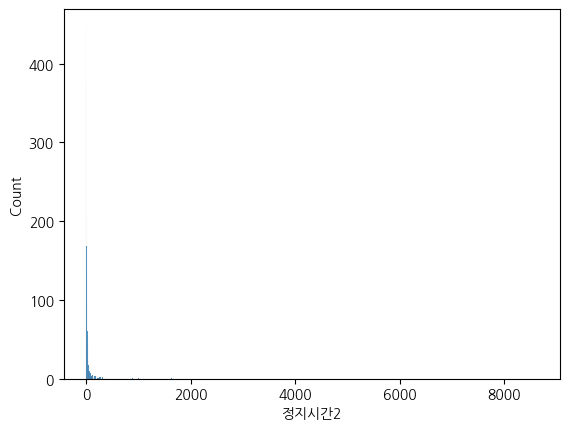

In [36]:
sns.histplot(data=df1_error, x='정지시간2')

<Axes: xlabel='정지시간2', ylabel='Count'>

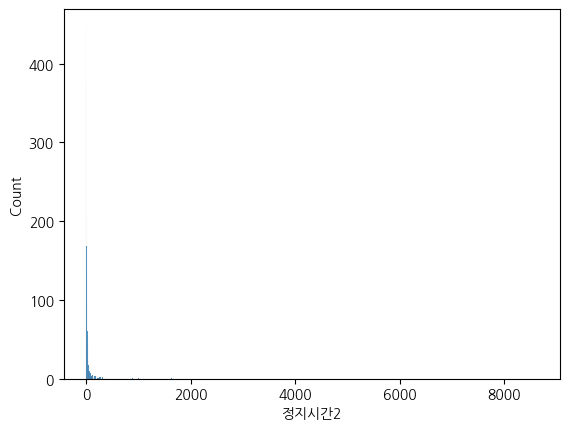

In [37]:
sns.histplot(data=df1_error, x='정지시간2')

<Axes: xlabel='정지시간2', ylabel='Count'>

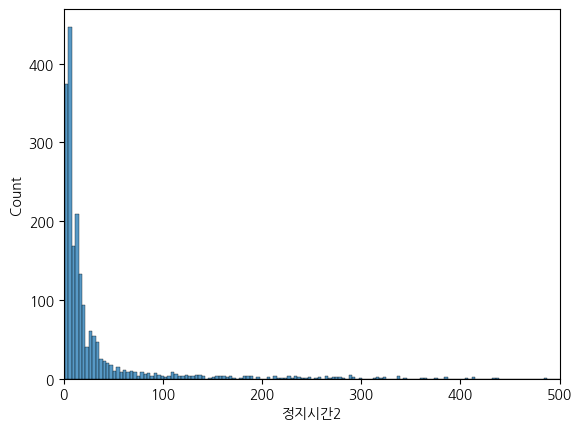

In [38]:
# 이상치로 인해 데이터 분포의 범위가 넓게 나타나고 있다.

plt.xlim([0,500])
sns.histplot(data=df1_error, x='정지시간2')

<Axes: xlabel='정지시간2', ylabel='Count'>

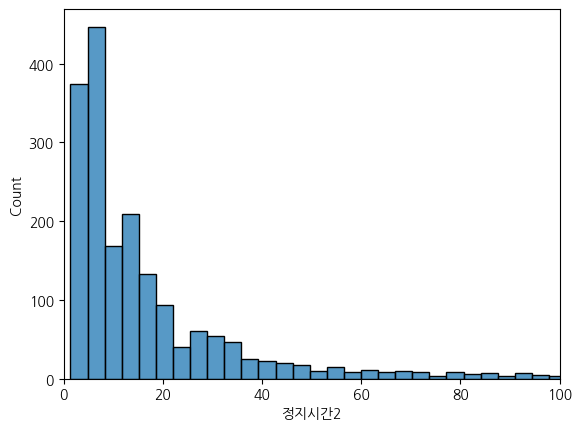

In [39]:
plt.xlim([0,100])
sns.histplot(data=df1_error, x='정지시간2')

### [해석]

### P.value < 0.05
### 통계적 결론 : 대립가설 참
### 사실적 결론 : '정지시간2' 데이터의 분포가 정규분포를 띄지 않을 것이다.

<Axes: xlabel='메세지', ylabel='정지시간2'>

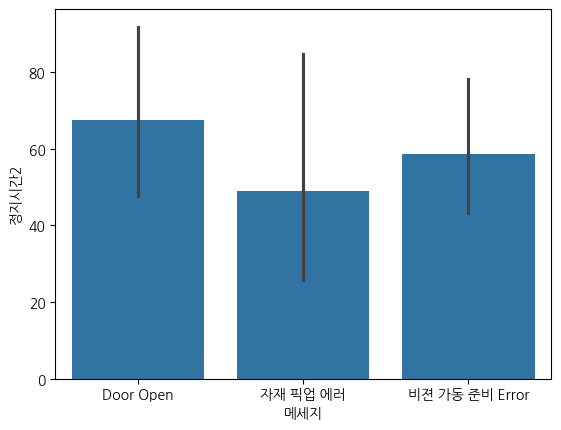

In [40]:
# 비정규분포에 대한 집단간 평균 비교 (비모수적 검정)  - 비교대상이 3집단이다.

# 귀무가설 : 각 집단의 평균의 차이가 없다.
# 대립가설 : 각 집단의 평균의 차이가 있다.

sns.barplot(data=df1_error, x='메세지', y='정지시간2')

In [41]:
cond1 = (df1_error['메세지'] == 'Door Open')
cond2 = (df1_error['메세지'] == '자재 픽업 에러')
cond3 = (df1_error['메세지'] == '비젼 가동 준비 Error')

df1_door = df1_error.loc[cond1]
df1_pick = df1_error.loc[cond2]
df1_vision = df1_error.loc[cond3]

In [42]:
stats.kruskal(df1_door['정지시간2'], df1_pick['정지시간2'], df1_vision['정지시간2'])

KruskalResult(statistic=np.float64(11.874092141392854), pvalue=np.float64(0.002639815974990724))

### [해석]

### P.value < 0.05
### 통계적 결론 : 대립가설 참
### 사실적 결론 : 발생하는 핵심 에러 별 조치시간의 차이가 명확히 존재한다.

# 가장 오류가 많이 발생하고 있는 Door Open 에러에 대해 자세히 살펴보자

In [43]:
cond1 = (df1['메세지'] == 'Door Open')
df1_dooropen = df1.loc[cond1]

df1_dooropen

,메세지,발생시간,조치시간,정지시간,정지시간2,모델,제품두께,제품싸이즈,작업구분,작업자,온도,습도
1,Door Open,2015-06-17T07:32:42,2015-06-17T07:32:54,0시 00분 12초,11.970,78FBGA 7.5x11 CGHB08154 REV.1,0.25,415-515,야간,이은미,22.5,47.3
3,Door Open,2015-06-17T07:36:25,2015-06-17T07:36:29,0시 00분 04초,4.093,78FBGA 7.5x11 CGHB08154 REV.3,2.25,415-517,야간,이은미,22.5,47.3
4,Door Open,2015-06-17T07:37:54,2015-06-17T07:41:58,0시 04분 04초,244.350,78FBGA 7.5x11 CGHB08154 REV.4,3.25,415-518,야간,이은미,22.5,47.3
6,Door Open,2015-06-17T07:43:32,2015-06-17T07:43:40,0시 00분 08초,8.188,78FBGA 7.5x11 CGHB08154 REV.6,5.25,415-520,야간,이은미,22.5,47.3
8,Door Open,2015-06-17T07:44:44,2015-06-17T07:44:52,0시 00분 08초,7.984,78FBGA 7.5x11 CGHB08154 REV.8,7.25,415-522,야간,이은미,22.5,47.3
...,...,...,...,...,...,...,...,...,...,...,...,...
2781,Door Open,2015-06-24T11:57:09,2015-06-24T11:57:25,0시 00분 16초,15.941,NaN,NaN,NaN,주간,NaN,22.5,47.3
2783,Door Open,2015-06-24T11:59:16,2015-06-24T11:59:26,0시 00분 10초,10.002,NaN,NaN,NaN,주간,NaN,22.5,47.3
2786,Door Open,2015-06-24T12:23:40,2015-06-24T12:23:48,0시 00분 08초,7.970,NaN,NaN,NaN,주간,NaN,22.5,47.3
2788,Door Open,2015-06-24T12:54:42,2015-06-24T12:55:08,0시 00분 26초,25.956,NaN,NaN,NaN,주간,NaN,22.5,47.3


In [44]:
# 같은 오류내에서 야간과 주간의 차이가 있을까?

df1_dooropen.pivot_table(index='작업구분', values='정지시간2', aggfunc='mean')

,정지시간2
작업구분,
야간,55.083103
주간,78.958169


<Axes: xlabel='정지시간2', ylabel='Count'>

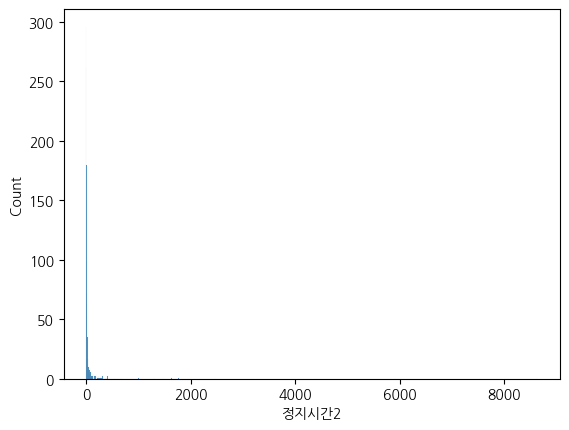

In [45]:
# 야간과 주간의 차이가 존재한다.
# 같은 문제이면 조치시간은 동일해야 하는 것이 아닌가?

# 2-1. Door Open Error의 정지시간의 분포가 정규분포인지 아닌지 확인해보자
# 귀무가설 : Door Open Error의 정지시간의 분포가 정규분포이다.
# 대립가설 : Door Open Error의 정지시간의 분포가 정규분포가 아니다.

sns.histplot(data=df1_dooropen, x='정지시간2')

<Axes: xlabel='정지시간2', ylabel='Count'>

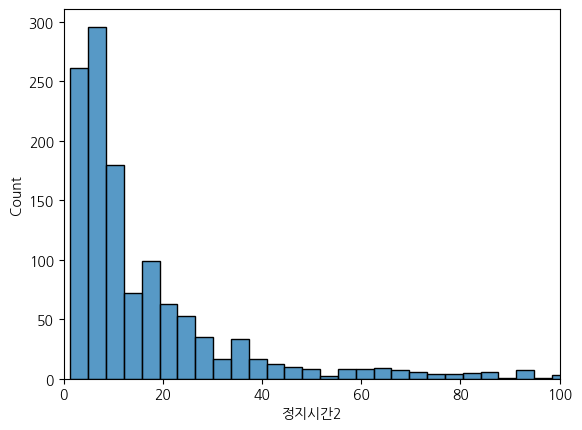

In [46]:
plt.xlim([0,100])
sns.histplot(data=df1_dooropen, x='정지시간2')

In [47]:
# 정규분포를 띄지 않고 있다.

stats.normaltest(df1_dooropen['정지시간2'])

NormaltestResult(statistic=np.float64(2647.03980170818), pvalue=np.float64(0.0))

### [해석]

### P.value < 0.05
### 통계적 결론 : 대립가설 참
### 사실적 결론 : Door Open Error의 정지시간의 분포가 정규분포가 아니다.

# 2-2. 비정규분포   -> ranksums 함수를 이용

# 귀무가설 : 주간작업과 야간작업의 정지시간의 평균의 차이가 없다.
# 대립가설 : 주간작업과 야간작업의 정지시간의 편균의 차이가 있다.

In [48]:
cond1 = (df1_dooropen['작업구분'] == '주간')
cond2 = (df1_dooropen['작업구분'] == '야간')

df1_door_days = df1_dooropen.loc[cond1]
df1_door_night = df1_dooropen.loc[cond2]

In [49]:
stats.ranksums(df1_door_days['정지시간2'], df1_door_night['정지시간2'])

RanksumsResult(statistic=np.float64(1.663870780217619), pvalue=np.float64(0.09613825542066314))

### [해석]

### P.value > 0.05
### 통계적 결론 : 귀무가설 참
#### 사실적 결론 : 주간작업과 야간작업의 정지시간의 평균의 차이가 없다.

#### --------------------------------------------------------------------------------------------------------------
#### 앞에서 시각화 및 단순통계를 통해 확인된 야간과 주간의 정지시간의 차이가 존재하는 것을 확인했다.
#### 그런데 결론은 야간과 주간에 동일한 문제가 발생한 경우 이를 적절하게 조치하고 있었다.
### --------------------------------------------------------------------------------------------------------
##   단순 통계량과 시각화를 통해서 의사결정을 내리면 안된다.
##   반드시 가설검정을 통해 내가 원하는 사실과 명제를 참인지 거짓인지 확인하는 절차를 걸쳐야 한다.

# [마무리]

# 다른 요소에 대해 직접 실습을 진행하여 확인해보자


## 이 단계가 익숙해져야 도출된 인사이트에 대해 논리적으로 설명이 가능하다.